Import libraries and modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np



Positional Embedding

In [ ]:
class PositionalEmbedding(nn.Module):
  def __init__(self, width, max_seq_length):
    super().__init__()

    pe = torch.zeros(max_seq_length, width)

    for pos in range(max_seq_length):
      for i in range(width):
        if i % 2 == 0:
          pe[pos][i] = np.sin(pos/(10000 ** (i/width)))
        else:
          pe[pos][i] = np.cos(pos/(10000 ** ((i-1)/width)))

    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):

    x = x + self.pe

    return x

Attention Head

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, width, head_size):
        super().__init__()

        self.head_size = head_size

        self.query = nn.Linear(width, head_size)
        self.key   = nn.Linear(width, head_size)
        self.value = nn.Linear(width, head_size)

    def forward(self, x, mask=None):

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attention = Q @ K.transpose(-2, -1)

        attention = attention / (self.head_size ** 0.5)

        # Applying Attention Mask
        if mask is not None:
          mask = mask.unsqueeze(1)   # (batch,1,seq_len)
          attention = attention.masked_fill(mask == 0, float("-inf"))
        attention = torch.softmax(attention, dim=-1)

        out = attention @ V

        return out

Multi-Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, width, n_heads):
    super().__init__()
    self.head_size = width // n_heads

    self.W_o = nn.Linear(width, width)

    self.heads = nn.ModuleList([AttentionHead(width, self.head_size) for _ in range(n_heads)])

  def forward(self, x, mask=None):
    # Combine attention heads
    out = torch.cat([head(x, mask=mask) for head in self.heads], dim=-1)

    out = self.W_o(out)

    return out

Transformer Encoder

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, width, n_heads, r_mlp=4):
        super().__init__()
        self.width = width
        self.n_heads = n_heads

        # Sub-Layer 1 Normalization
        self.ln1 = nn.LayerNorm(width)

        # Multi-Head Attention
        self.mha = MultiHeadAttention(width, n_heads)

        # Sub-Layer 2 Normalization
        self.ln2 = nn.LayerNorm(width)

        # Multilayer Perception
        self.mlp = nn.Sequential(
            nn.Linear(self.width, self.width*r_mlp),
            nn.GELU(),
            nn.Linear(self.width*r_mlp, self.width)
        )


    def forward(self, x, mask=None):
        x = x + self.mha(self.ln1(x), mask=mask)

        x = x + self.mlp(self.ln2(x))

        return x

Tokenization

In [ ]:
def tokenizer(text, encode=True, mask=None, max_seq_length=32):

    if encode:
        out = chr(2) + text + chr(3)

        out = out[:max_seq_length]
        out = out + "".join(chr(0) for _ in range(max_seq_length - len(out)))

        out = torch.IntTensor(list(out.encode("utf-8")))

        mask = (out != 0).int()

    else:
        length = int(mask.sum())
        out = "".join(chr(int(x)) for x in text[1:length-1])
        mask = None

    return out, mask

Text Encoder

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, width, max_seq_length, n_heads, n_layers, emb_dim):
        super().__init__()

        self.max_seq_length = max_seq_length

        self.encoder_embedding = nn.Embedding(vocab_size, width)

        self.positional_embedding = PositionalEmbedding(width, max_seq_length)

        self.encoder = nn.ModuleList([TransformerEncoder(width,n_heads) for _ in range(n_layers)])

        # learned proj of image to embed
        self.projection = nn.Parameter(torch.randn(width, emb_dim))

    def forward(self, text, mask=None):
        # Text Embedding
        x = self.encoder_embedding(text)

        # Positional Embedding
        x = self.positional_embedding(x)

        # Transformer Encoder
        for encoder_layer in self.encoder:
            x = encoder_layer(x, mask=mask)

        # Takes features from the EOT Embedding
        eot_indices = mask.sum(dim=1) - 1
        x = x[torch.arange(text.shape[0]), eot_indices]

        # joint multimodal embedding
        if self.projection is not None:
            x = x @ self.projection

        x = x / torch.norm(x, dim=-1, keepdim=True)

        return x

Image Encoder

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self, width, img_size, patch_size, n_channels, n_layers, n_heads, emb_dim):
        super().__init__()

        assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0, "img_size dimensions must be divisible by patch_size dimensions"
        assert width % n_heads == 0, "width must be divisible by n_heads"

        self.n_patches = (img_size[0] * img_size[1]) // (patch_size[0] * patch_size[1])

        self.max_seq_length = self.n_patches + 1

        self.linear_project = nn.Conv2d(n_channels, width, kernel_size=patch_size, stride=patch_size)

        self.cls_token = nn.Parameter(torch.randn(1, 1, width))

        self.positional_embedding = PositionalEmbedding(width,self.max_seq_length)

        self.encoder = nn.ModuleList([TransformerEncoder(width,n_heads) for _ in range(n_layers)])


        # learned proj of image to embed
        self.projection = nn.Parameter(torch.randn(width, emb_dim))


    def forward(self,x):
        # Patch Embedding
        x = self.linear_project(x)
        x = x.flatten(2).transpose(1, 2)

        # Positional Embedding
        x = torch.cat((self.cls_token.expand(x.size()[0], -1, -1),x), dim=1)
        x = self.positional_embedding(x)

        # Transformer Encoder
        for encoder_layer in self.encoder:
            x = encoder_layer(x)

        # Getting Class Tokens
        x = x[:, 0, :]

        # joint multimodal embedding
        if self.projection is not None:
            x = x @ self.projection

        x = x / torch.norm(x, dim=-1, keepdim=True)

        return x

CLIP Model


In [ ]:
class CLIP(nn.Module):
    def __init__(
        self,
        emb_dim,
        vit_width,
        img_size,
        patch_size,
        n_channels,
        vit_layers,
        vit_heads,
        vocab_size,
        text_width,
        max_seq_length,
        text_heads,
        text_layers
    ):
        super().__init__()

        # Image Encoder
        self.image_encoder = ImageEncoder(
            vit_width,
            img_size,
            patch_size,
            n_channels,
            vit_layers,
            vit_heads,
            emb_dim
        )

        # Text Encoder
        self.text_encoder = TextEncoder(
            vocab_size,
            text_width,
            max_seq_length,
            text_heads,
            text_layers,
            emb_dim
        )

        # Learnable temperature parameter
        self.temperature = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, image, text, mask=None):

        # Encode images and text
        image_embeddings = self.image_encoder(image)
        text_embeddings = self.text_encoder(text, mask=mask)

        # Cosine similarity logits
        logit_scale = self.temperature.exp().clamp(max=100)

        logits = image_embeddings @ text_embeddings.T
        logits = logits * logit_scale

        # Ground truth labels
        labels = torch.arange(logits.size(0), device=logits.device)

        # Symmetric CLIP loss
        image_loss = nn.functional.cross_entropy(logits, labels)
        text_loss = nn.functional.cross_entropy(logits.T, labels)

        loss = (image_loss + text_loss) / 2

        return loss

Dataset

In [ ]:
from torchvision.datasets import FashionMNIST as TorchFashionMNIST

class FashionMNIST(Dataset):
    def __init__(self, train=True):

        self.dataset = TorchFashionMNIST(
            root="./data",
            train=train,
            download=True
        )

        self.transform = T.ToTensor()

        self.captions = {
            0: "An image of a t-shirt/top",
            1: "An image of trousers",
            2: "An image of a pullover",
            3: "An image of a dress",
            4: "An image of a coat",
            5: "An image of a sandal",
            6: "An image of a shirt",
            7: "An image of a sneaker",
            8: "An image of a bag",
            9: "An image of an ankle boot",
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        img, label = self.dataset[idx]

        img = self.transform(img)

        caption, mask = tokenizer(self.captions[label])

        return {
            "image": img,
            "caption": caption,
            "mask": mask
        }

Training Parameters

In [ ]:
emb_dim = 32
vit_width = 9
img_size = (28,28)
patch_size = (14,14)
n_channels = 1
vit_layers = 3
vit_heads = 3
vocab_size = 256
text_width = 32
max_seq_length = 32
text_heads = 8
text_layers = 4
lr = 1e-3
epochs = 10
batch_size = 128

Loading Dataset

In [ ]:
train_set = FashionMNIST(train = True)
test_set = FashionMNIST(train = False)

train_loader = DataLoader(train_set, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_set, shuffle=False, batch_size=batch_size)

Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    "Using device:",
    device,
    f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else ""
)

model = CLIP(
    emb_dim,
    vit_width,
    img_size,
    patch_size,
    n_channels,
    vit_layers,
    vit_heads,
    vocab_size,
    text_width,
    max_seq_length,
    text_heads,
    text_layers
).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)

best_loss = float("inf")

model.train()

for epoch in range(epochs):

    epoch_loss = 0.0

    for data in train_loader:

        img = data["image"].to(device)
        cap = data["caption"].to(device)
        mask = data["mask"].to(device)

        optimizer.zero_grad()

        loss = model(img, cap, mask)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss

        torch.save(model.state_dict(), "clip.pt")

        print("Model Saved.")

Using device: cuda (Tesla T4)
Epoch [1/10] Loss: 3.4754
Model Saved.
Epoch [2/10] Loss: 3.1259
Model Saved.
Epoch [3/10] Loss: 3.0781
Model Saved.
Epoch [4/10] Loss: 3.0503
Model Saved.
Epoch [5/10] Loss: 3.0316
Model Saved.
Epoch [6/10] Loss: 3.0170
Model Saved.
Epoch [7/10] Loss: 3.0091
Model Saved.
Epoch [8/10] Loss: 2.9947
Model Saved.
Epoch [9/10] Loss: 2.9876
Model Saved.
Epoch [10/10] Loss: 2.9814
Model Saved.


Testing

In [ ]:
# Load Best Model
model = CLIP(
    emb_dim,
    vit_width,
    img_size,
    patch_size,
    n_channels,
    vit_layers,
    vit_heads,
    vocab_size,
    text_width,
    max_seq_length,
    text_heads,
    text_layers
).to(device)

model.load_state_dict(torch.load("clip.pt", map_location=device))
model.eval()

# Encode all captions once
text = torch.stack(
    [tokenizer(x)[0] for x in test_set.captions.values()]
).to(device)

mask = torch.stack(
    [tokenizer(x)[1] for x in test_set.captions.values()]
).to(device)

correct = 0
total = 0

with torch.no_grad():

    text_features = model.text_encoder(text, mask=mask)

    for data in test_loader:

        images = data["image"].to(device)
        labels = data["caption"].to(device)

        image_features = model.image_encoder(images)

        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        indices = similarity.argmax(dim=1)

        predictions = torch.stack(
            [tokenizer(test_set.captions[int(i)])[0] for i in indices]
        ).to(device)

        correct += (predictions == labels).all(dim=1).sum().item()
        total += labels.size(0)

print(f"Model Accuracy: {100 * correct / total:.2f}%")

Model Accuracy: 84.91%


Zero-Shot Classification

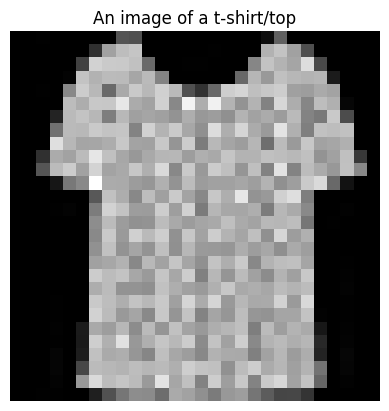


Top Predictions:

           shirt: 94.46%
     t-shirt/top: 5.54%
        pullover: 0.00%
           dress: 0.00%
        trousers: 0.00%


In [ ]:
# Captions to compare images to
class_names = [
    "t-shirt/top",
    "trousers",
    "pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankle boot"
]

# Encode text prompts
text = torch.stack(
    [tokenizer(x)[0] for x in class_names]
).to(device)

mask = torch.stack(
    [tokenizer(x)[1] for x in class_names]
).to(device)

idx = 1000

sample = test_set[idx]
img = sample["image"].unsqueeze(0)

plt.imshow(img[0].permute(1, 2, 0), cmap="gray")
plt.title(tokenizer(sample["caption"], encode=False, mask=sample["mask"])[0])
plt.axis("off")
plt.show()

img = img.to(device)

model.eval()

with torch.no_grad():

    image_features = model.image_encoder(img)
    text_features = model.text_encoder(text, mask=mask)

    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

values, indices = similarity[0].topk(5)

print("\nTop Predictions:\n")

for value, index in zip(values, indices):
    print(f"{class_names[index]:>16s}: {100 * value.item():.2f}%")